In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading data
df = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [11]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
print('Number of rows in the Data are:', df.shape[0])
print('Number of columns in the Data are:', df.shape[1])

Number of rows in the Data are: 301
Number of columns in the Data are: 9


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [90]:
df.duplicated().sum()

np.int64(2)

In [91]:
df_cleaned = df.drop_duplicates()
df_cleaned

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [92]:
df_cleaned['Car_Name'] = df_cleaned['Car_Name'].replace({
    '800':'alto 800',
    'Bajaj Avenger 150' : 'Bajaj Avenger 150 street',
    'Bajaj Avenger 220' : 'Bajaj Avenger 220 dtsi',
    'Bajaj Avenger Street 220' : 'Bajaj Avenger 220 dtsi',
    'corolla' : 'corolla altis',
    'etios gd' : 'etios g'
})
df_cleaned.Car_Name.value_counts()

/tmp/ipykernel_2516/834470480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Car_Name'] = df_cleaned['Car_Name'].replace({


,count
Car_Name,
city,26
corolla altis,17
verna,14
fortuner,10
brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [106]:
df_cleaned.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


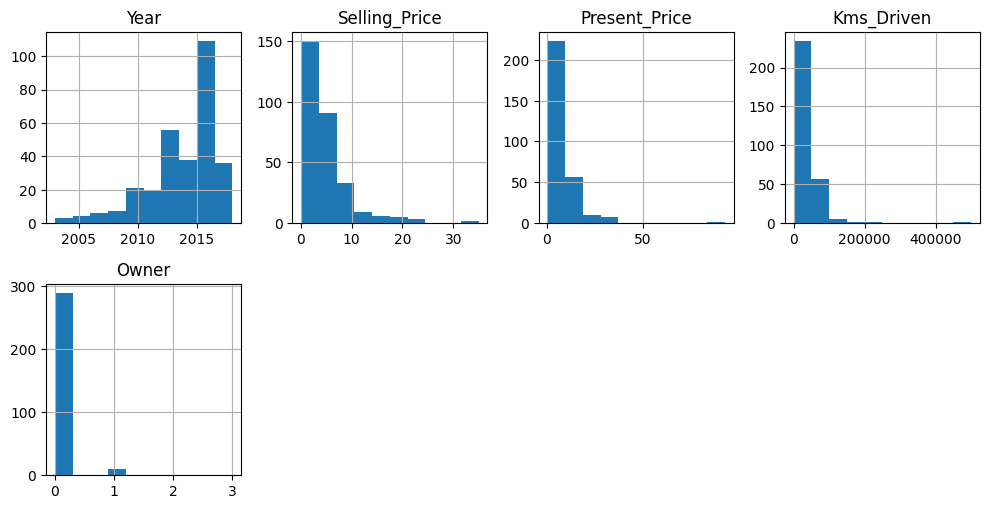

In [93]:
df_cleaned.hist(layout=[4,4], figsize=(10,10))
plt.tight_layout()
plt.show()

# Outliers Findings

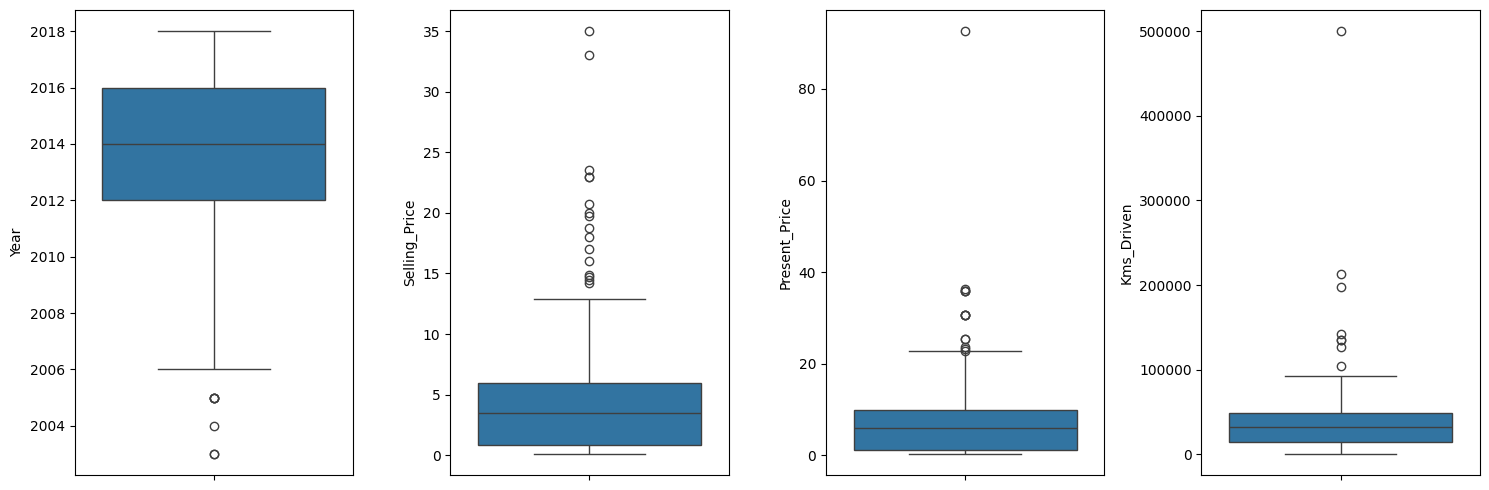

In [111]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
sns.boxplot(df_cleaned.Year)


plt.subplot(1, 4, 2)
sns.boxplot(df_cleaned.Selling_Price)


plt.subplot(1, 4, 3)
sns.boxplot(df_cleaned.Present_Price)


plt.subplot(1, 4, 4)
sns.boxplot(df_cleaned.Kms_Driven)
plt.tight_layout()
plt.show()

In [118]:
Q1 = df_cleaned['Selling_Price'].quantile(0.25)
Q3 = df_cleaned['Selling_Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['Selling_Price'] < lower) |
              (df_cleaned['Selling_Price'] > upper)]

outliers = outliers.sort_values(by='Selling_Price')

outliers

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
69,corolla altis,2016,14.25,20.91,12000,Petrol,Dealer,Manual,0
79,fortuner,2012,14.50,30.61,89000,Diesel,Dealer,Automatic,0
80,corolla altis,2016,14.73,14.89,23000,Diesel,Dealer,Manual,0
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0
97,corolla altis,2017,17.00,18.64,8700,Petrol,Dealer,Manual,0
52,innova,2017,18.00,19.77,15000,Diesel,Dealer,Automatic,0
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0
66,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0


In [119]:
Q1 = df_cleaned['Year'].quantile(0.25)
Q3 = df_cleaned['Year'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['Year'] < lower) |
              (df_cleaned['Year'] > upper)]

outliers = outliers.sort_values(by='Year')

outliers

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
37,alto 800,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
39,sx4,2003,2.25,7.98,62000,Petrol,Dealer,Manual,0
77,corolla altis,2004,1.50,12.35,135154,Petrol,Dealer,Automatic,0
54,innova,2005,2.75,10.21,90000,Petrol,Individual,Manual,0
84,innova,2005,3.49,13.46,197176,Diesel,Dealer,Manual,0
92,innova,2005,3.51,13.70,75000,Petrol,Dealer,Manual,0
189,Hero Super Splendor,2005,0.20,0.57,55000,Petrol,Individual,Manual,0


In [120]:
Q1 = df_cleaned['Present_Price'].quantile(0.25)
Q3 = df_cleaned['Present_Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['Present_Price'] < lower) |
              (df_cleaned['Present_Price'] > upper)]

outliers = outliers.sort_values(by='Present_Price')

outliers

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
78,corolla altis,2010,5.25,22.83,80000,Petrol,Dealer,Automatic,0
66,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0
85,camry,2006,2.50,23.73,142000,Petrol,Individual,Automatic,3
82,innova,2017,23.00,25.39,15000,Diesel,Dealer,Automatic,0
96,innova,2016,20.75,25.39,29000,Diesel,Dealer,Automatic,0
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
79,fortuner,2012,14.50,30.61,89000,Diesel,Dealer,Automatic,0
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0


In [121]:
Q1 = df_cleaned['Kms_Driven'].quantile(0.25)
Q3 = df_cleaned['Kms_Driven'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['Kms_Driven'] < lower) |
              (df_cleaned['Kms_Driven'] > upper)]

outliers = outliers.sort_values(by='Kms_Driven')

outliers

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0
37,alto 800,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0
77,corolla altis,2004,1.50,12.35,135154,Petrol,Dealer,Automatic,0
85,camry,2006,2.50,23.73,142000,Petrol,Individual,Automatic,3
84,innova,2005,3.49,13.46,197176,Diesel,Dealer,Manual,0
179,Honda Karizma,2010,0.31,1.05,213000,Petrol,Individual,Manual,0
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


**Outliers were identified using the IQR method and manually reviewed. Since the identified values represented genuine observations, they were retained.**

**Distribution of Vehicles by Fuel Type**

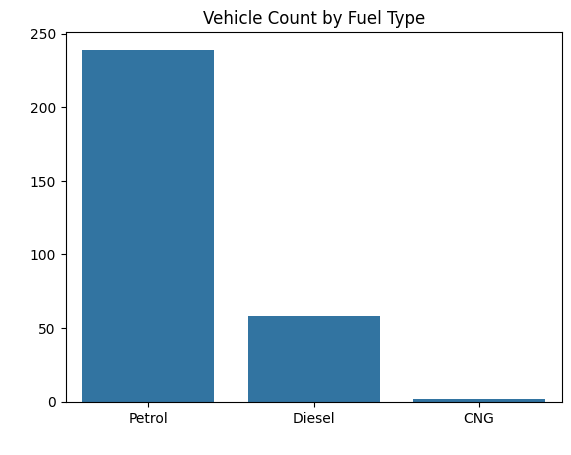

In [94]:
sns.barplot(x=df_cleaned.Fuel_Type.value_counts().index, y=df_cleaned.Fuel_Type.value_counts())
plt.title('Vehicle Count by Fuel Type')
plt.xlabel(' ')
plt.ylabel(' ')
plt.show()

**Vehicle Distribution by Year**

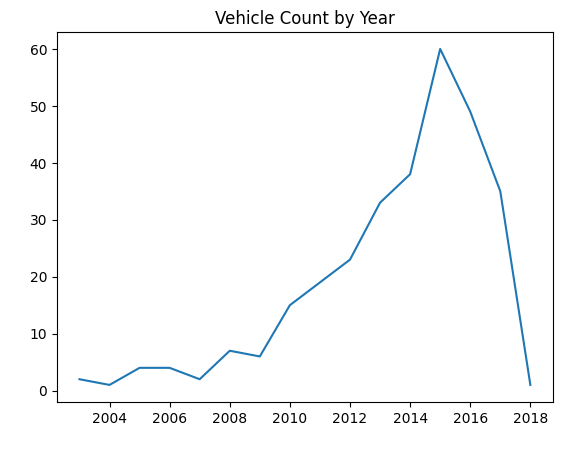

In [95]:
sns.lineplot(x=df_cleaned.Year.value_counts().index, y=df_cleaned.Year.value_counts())
plt.title('Vehicle Count by Year')
plt.xlabel(' ')
plt.ylabel(' ')
plt.show()

**Seller Type Distribution**

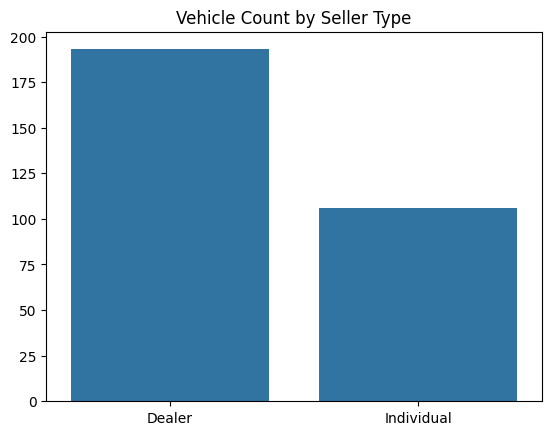

In [96]:
sns.barplot(x=df_cleaned.Seller_Type.value_counts().index, y=df_cleaned.Seller_Type.value_counts())
plt.title('Vehicle Count by Seller Type')
plt.xlabel('')
plt.ylabel('')
plt.show()

**Transmission Type Distribution**

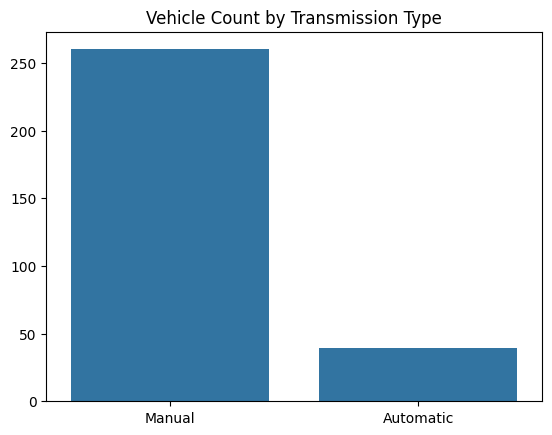

In [98]:
sns.barplot(x=df_cleaned.Transmission.value_counts().index, y=df_cleaned.Transmission.value_counts())
plt.title('Vehicle Count by Transmission Type')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [128]:
df_cleaned.Transmission.value_counts()

,count
Transmission,
Manual,260
Automatic,39


**Vechile Count by Owners**

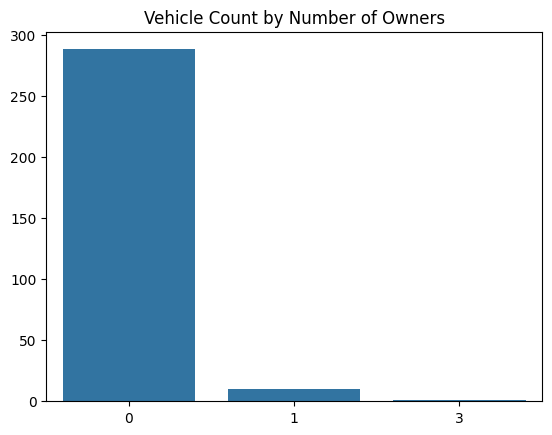

In [99]:
sns.barplot(x=df_cleaned.Owner.value_counts().index, y=df_cleaned.Owner.value_counts())
plt.title('Vehicle Count by Number of Owners')
plt.xlabel('')
plt.ylabel('')
plt.show()

**Present Price vs Selling Price vs Kilometers Driven**

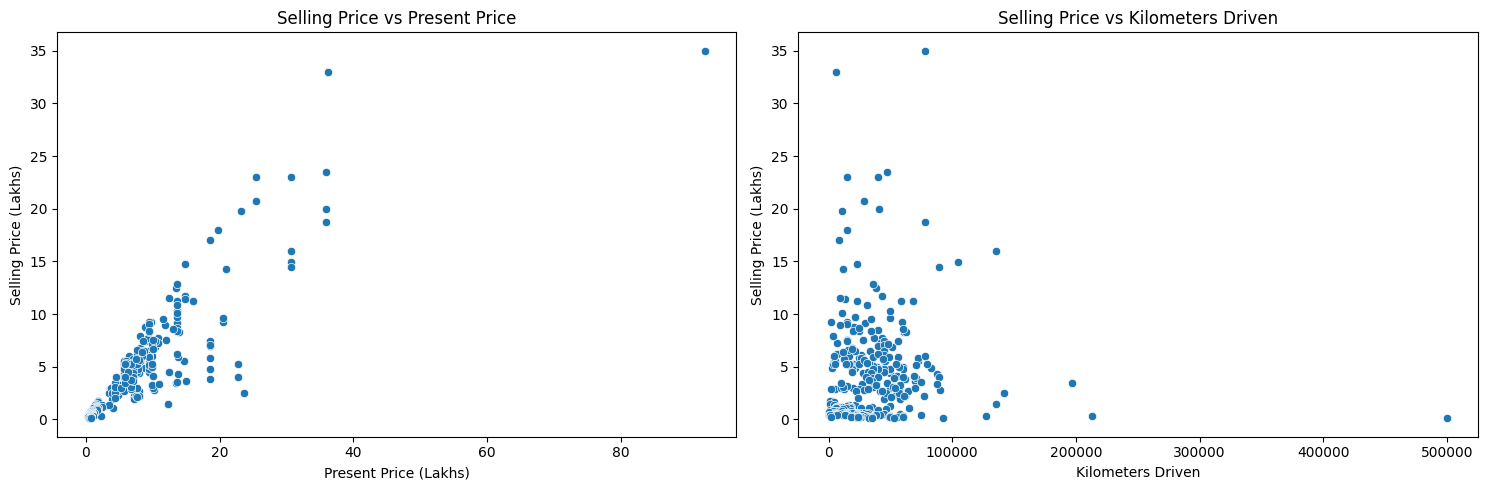

In [100]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df_cleaned)
plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df_cleaned)
plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

**Selling Price Analysis by Vehicle Attributes**

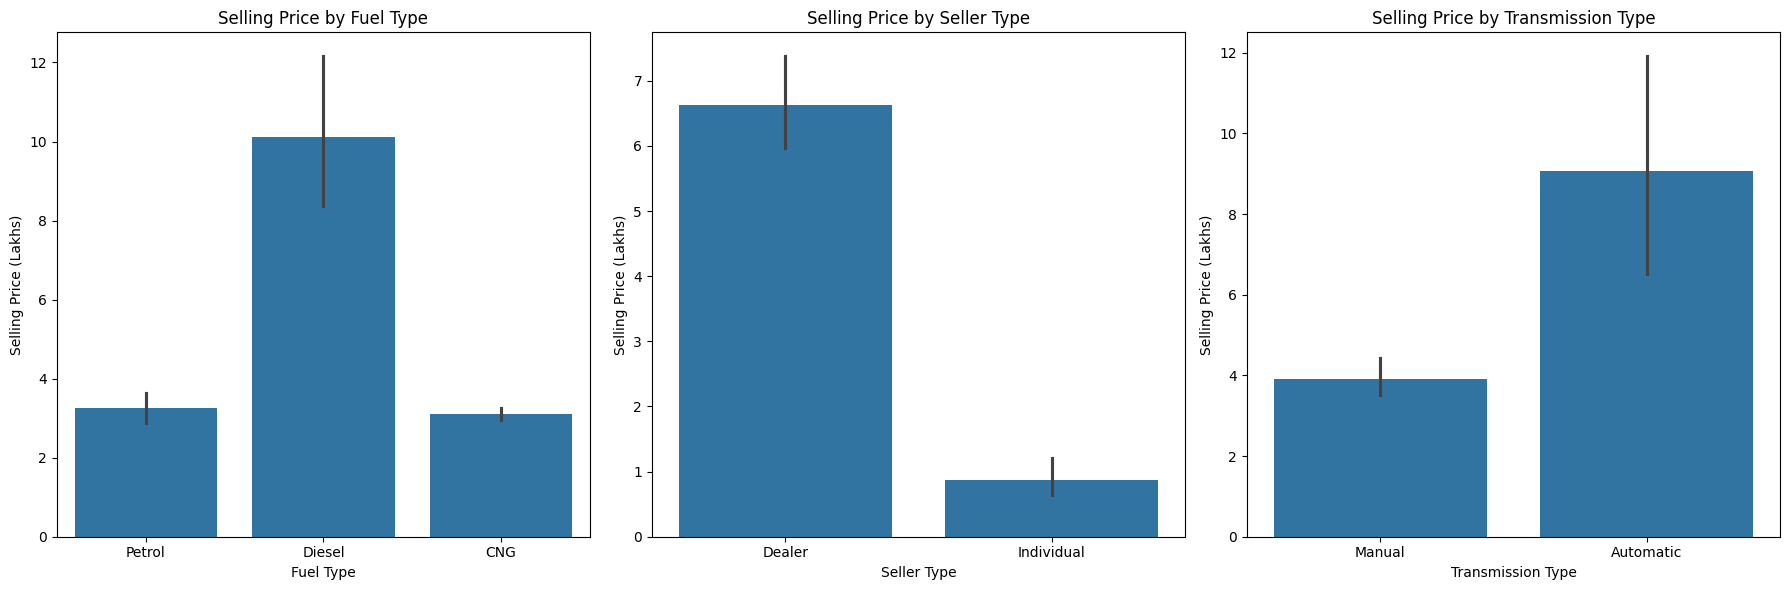

In [101]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Fuel_Type', y='Selling_Price', data=df_cleaned)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(1, 3, 2)
sns.barplot(x='Seller_Type', y='Selling_Price', data=df_cleaned)
plt.title('Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(1, 3, 3)
sns.barplot(x='Transmission', y='Selling_Price', data=df_cleaned)
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

Top Cars Names

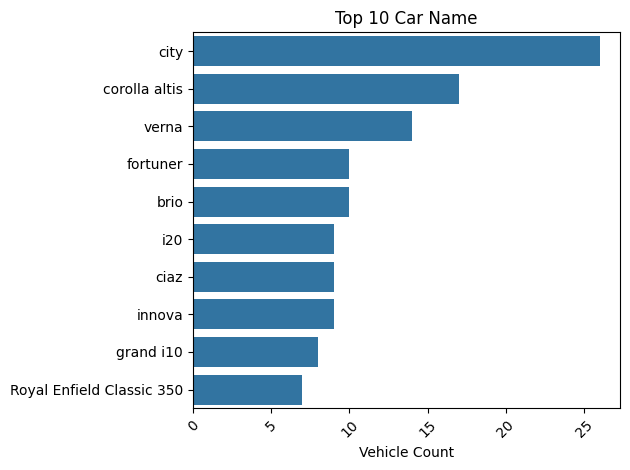

In [102]:
top10 = df_cleaned['Car_Name'].value_counts().head(10)

sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 Car Name')
plt.ylabel('')
plt.xlabel('Vehicle Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dashboard

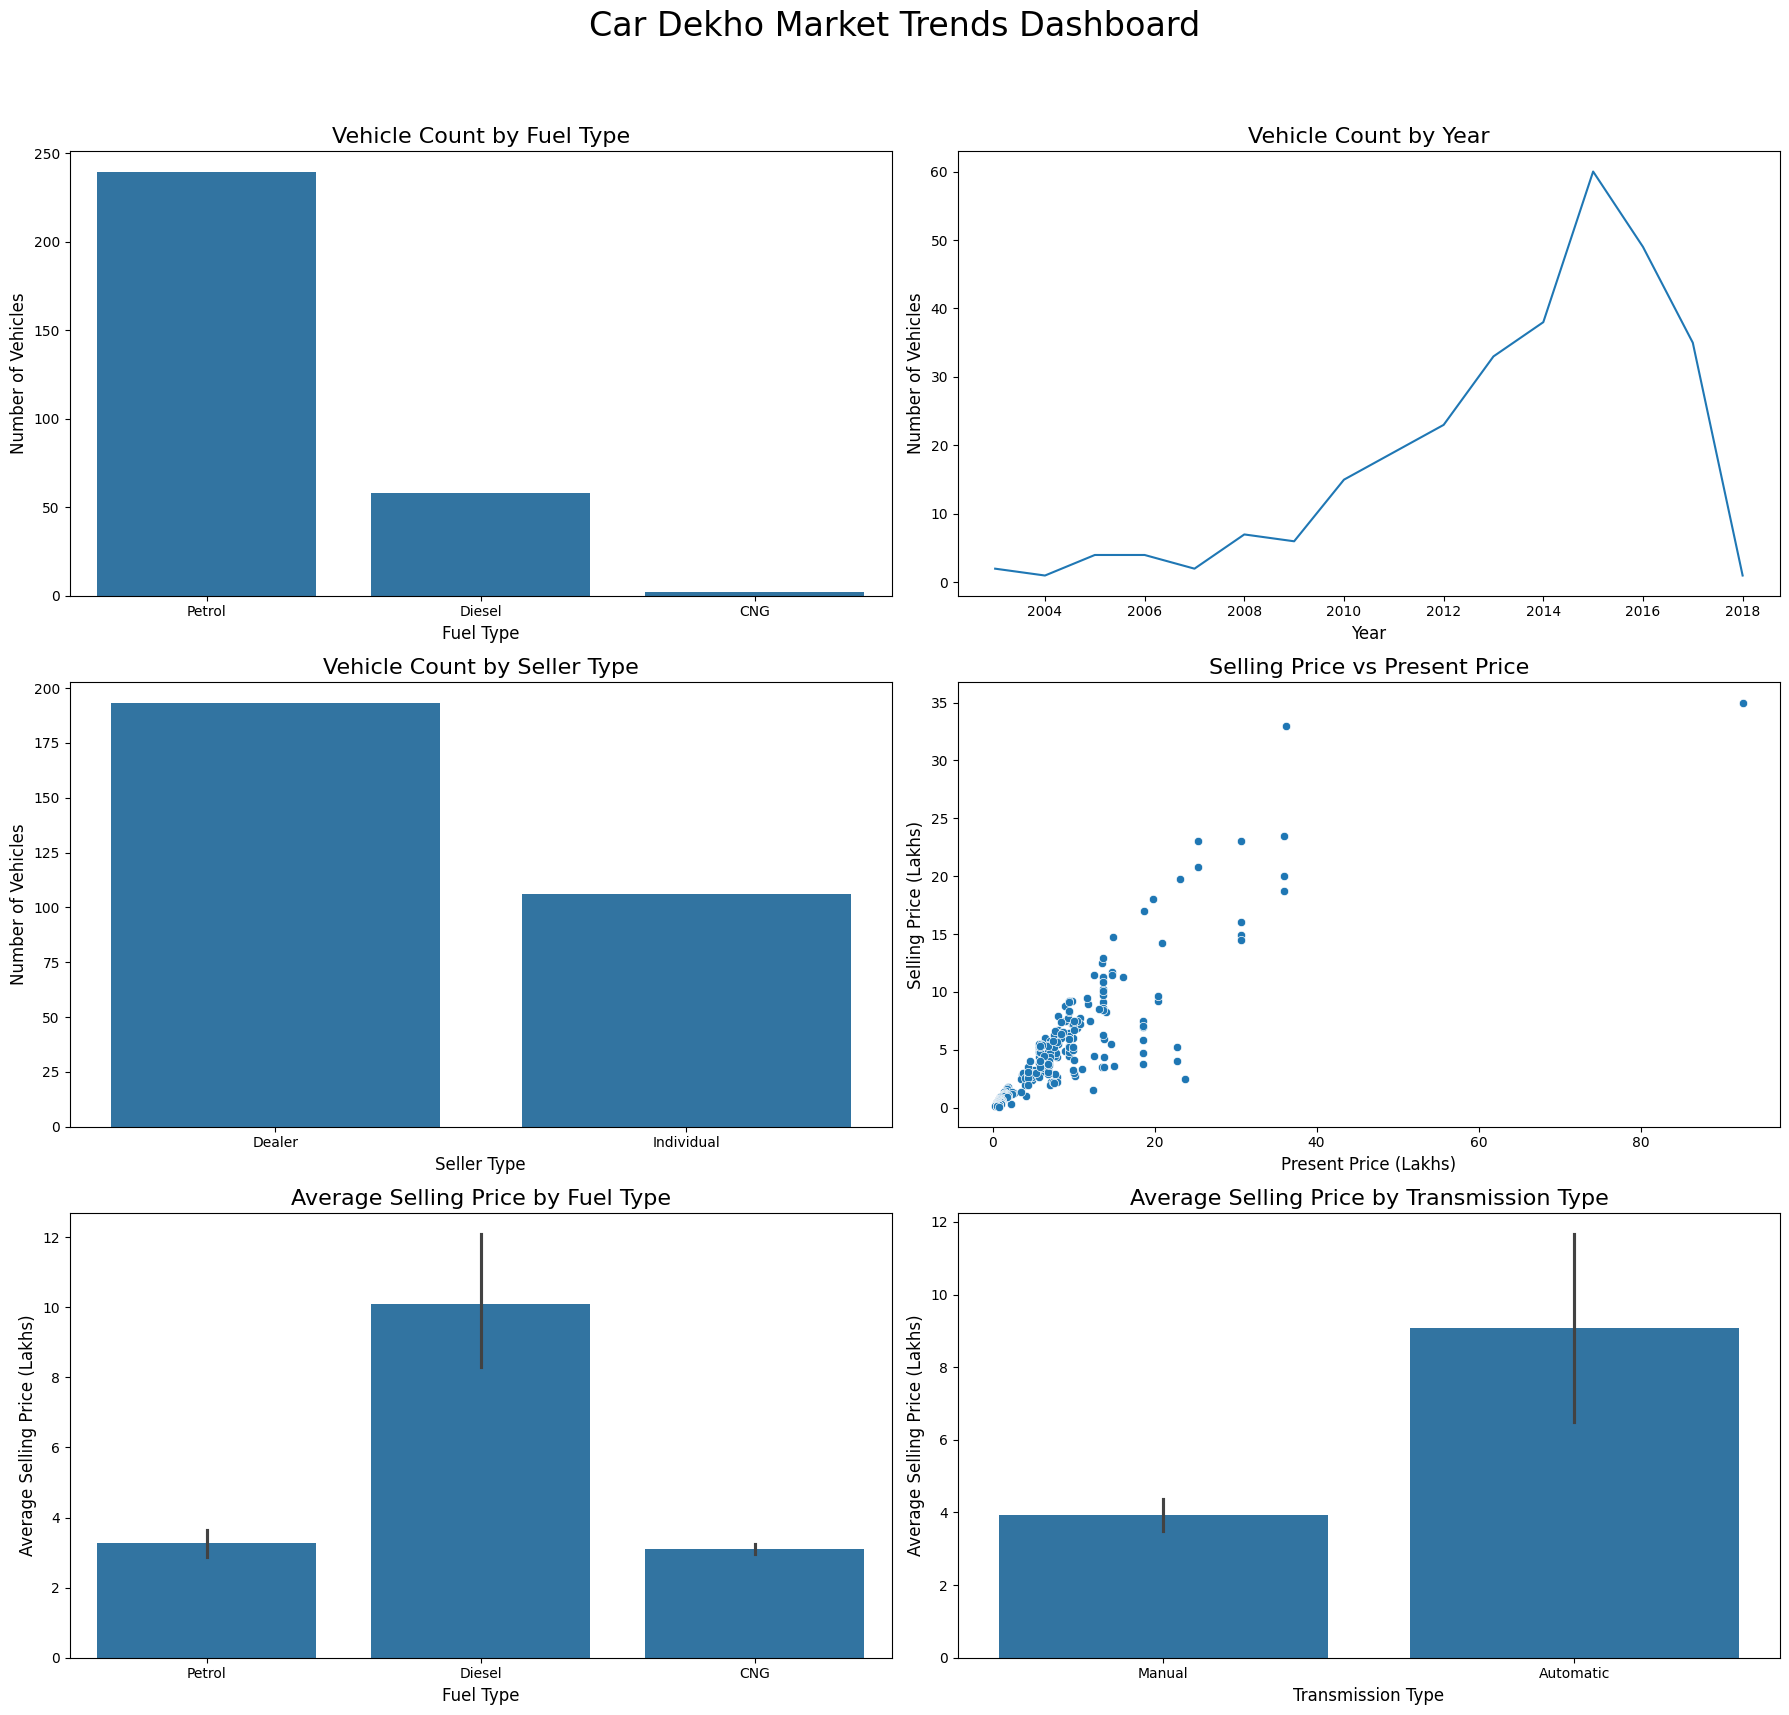

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [143]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
fig.suptitle('Car Dekho Market Trends Dashboard', fontsize=24)

# Plot 1: Vehicle Count by Fuel Type
sns.barplot(x=df_cleaned.Fuel_Type.value_counts().index, y=df_cleaned.Fuel_Type.value_counts(), ax=axes[0, 0])
axes[0, 0].set_title('Vehicle Count by Fuel Type', fontsize=16)
axes[0, 0].set_xlabel('Fuel Type', fontsize=12)
axes[0, 0].set_ylabel('Number of Vehicles', fontsize=12)

# Plot 2: Vehicle Count by Year
sns.lineplot(x=df_cleaned.Year.value_counts().index, y=df_cleaned.Year.value_counts(), ax=axes[0, 1])
axes[0, 1].set_title('Vehicle Count by Year', fontsize=16)
axes[0, 1].set_xlabel('Year', fontsize=12)
axes[0, 1].set_ylabel('Number of Vehicles', fontsize=12)

# Plot 3: Vehicle Count by Seller Type
sns.barplot(x=df_cleaned.Seller_Type.value_counts().index, y=df_cleaned.Seller_Type.value_counts(), ax=axes[1, 0])
axes[1, 0].set_title('Vehicle Count by Seller Type', fontsize=16)
axes[1, 0].set_xlabel('Seller Type', fontsize=12)
axes[1, 0].set_ylabel('Number of Vehicles', fontsize=12)

# Plot 4: Selling Price vs Present Price
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df_cleaned, ax=axes[1, 1])
axes[1, 1].set_title('Selling Price vs Present Price', fontsize=16)
axes[1, 1].set_xlabel('Present Price (Lakhs)', fontsize=12)
axes[1, 1].set_ylabel('Selling Price (Lakhs)', fontsize=12)

# Plot 5: Selling Price by Fuel Type
sns.barplot(x='Fuel_Type', y='Selling_Price', data=df_cleaned, ax=axes[2, 0])
axes[2, 0].set_title('Average Selling Price by Fuel Type', fontsize=16)
axes[2, 0].set_xlabel('Fuel Type', fontsize=12)
axes[2, 0].set_ylabel('Average Selling Price (Lakhs)', fontsize=12)

# Plot 6: Selling Price by Transmission Type
sns.barplot(x='Transmission', y='Selling_Price', data=df_cleaned, ax=axes[2, 1])
axes[2, 1].set_title('Average Selling Price by Transmission Type', fontsize=16)
axes[2, 1].set_xlabel('Transmission Type', fontsize=12)
axes[2, 1].set_ylabel('Average Selling Price (Lakhs)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('Car_Dekho_Dashboard.png', dpi=300, bbox_inches='tight')

plt.show()

from google.colab import files
files.download('Car_Dekho_Dashboard.png')

**Key Insights Template**


*Overall Market*- The **dataset** contains **299 car** listings after removing **2 duplicate** record, covering **2003 to 2018**.

*Most Common Fuel Type*- **Petrol** is the most common fuel type, accounting for approximately 79.4% of the listings.

*Least Common Fuel Type*- **CNG** has the lowest representation, with 2 listings.

*Most Common Seller Type*- **Dealer** represents the largest share of listings with 193 cars.

*Selling Price by Fuel Type*- **Diesel** has the highest average selling price of approx ₹10 lakh, while **CNG & Petrol** has the similar average selling price approx ₹3.8 Lakh.

*Selling Price by Seller Type*- **Dealer** has the highest average selling price at ₹6.7 lakh, compared with ₹0.9 lakh for Individual.

*Transmission Preference*- **Automatic** cars dominate the dataset, representing 86% of total listings.

*Price by Transmission*- **Automatic** cars have a higher average selling price of ₹9.1 lakh compared with ₹3.9 lakh for Manual.

*Impact of Kilometers Driven* - The correlation between kilometers driven and selling price is approximately 0.029, indicating a very weak positive relationship. This suggests that kilometers driven has little to no linear relationship with selling price in this dataset.

*Most Listed Car Model* - **city** is the most frequently listed model, appearing more than 25 times in the dataset.

*Highest Selling Price* - The highest selling price recorded is ₹35 lakh, belonging to **land cruiser**.


***Key Overall Finding*** - Present Price has the strongest relationship with Selling Price, with a strong positive correlation of 0.879. This indicates that cars with higher present prices generally tend to have higher selling prices. In comparison, kilometers driven shows almost no linear relationship with selling price, with a correlation of only 0.029.

# **Conclusion**

The Car Dekho Market Trend was analyzed to understand the key factors influencing used-car selling prices. The analysis covered **299** car listings across **2003 to 2018**, with variables such as fuel type, seller type, transmission, vehicle age, present price, selling price, and kilometers driven.

The analysis indicates that **Present Price** has a noticeable relationship with selling price. **Diesel** cars recorded the highest average selling price, while **CNG and Petrol** had similar lower average selling prices. Similarly, Seller Type and Transmission Type showed differences in average selling prices.

A **strong positive** relationship was observed between **present price and selling price**, with a correlation of **0.879**. The analysis also suggests that **Kms Driven** has a **negligible positive** relationship with selling price.

Overall, the analysis provides useful insights into used-car pricing patterns and highlights the importance of factors such as **Present Price**, **Seller Type**, and **Transmission Type** when evaluating a car's resale value. These findings can help sellers and buyers better understand the factors associated with used-car prices.
